# Taller (Colab) — Regresión lineal múltiple: coeficientes, significancia y residuales

**Duración sugerida:** 50–60 min de trabajo + sustentación.

## Qué se evalúa hoy
1) **Interpretación de coeficientes** en regresión múltiple (cambio marginal, controlando por, unidades).
2) **Significancia por coeficiente** (t y p-valor, y coherencia con el IC).
3) **Lectura de residuales** (qué dicen y qué alertas sugieren).

---
## Definiciones mínimas (úsalas textual en la sustentación)

### A. Interpretación correcta de un coeficiente (plantilla obligatoria)
Para un predictor Xj:
> “Si Xj aumenta en **1 unidad**, la **nota esperada** cambia en **β̂j** puntos, **manteniendo constantes** los demás predictores del modelo.”

**Siempre debes mencionar:**
- signo (sube/baja),
- magnitud (cuánto),
- unidad (puntos de nota por unidad de Xj),
- y la frase “manteniendo constantes …”.

### B. Significancia (por coeficiente)
- Hipótesis: H0: βj = 0 vs H1: βj ≠ 0.
- t = β̂j / SE(β̂j).
- p-valor: evidencia contra H0 bajo los supuestos del modelo.

### C. Residuales (qué mirar)
- Residual = observado − predicho.
- Si hay patrón (curva/abanico) en residuales vs predichos → posible problema (no linealidad/heterocedasticidad).
- Outliers: residuales muy grandes en valor absoluto.


In [1]:
# 0) LIBRERÍAS (NO MODIFICAR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(2026)
pd.set_option('display.precision', 4)


## Contexto y variables (común para todos)

**Unidad:** estudiante.

**Y:** `nota` (0 a 5)

**X:**
- `horas` = horas de estudio por semana
- `asistencia` = porcentaje de asistencia (0–100)
- `promedio` = promedio previo (0–5)


In [2]:
# 1) SIMULACIÓN BASE (NO MODIFICAR)
n = 300
np.random.seed(2026)

promedio = np.clip(np.random.normal(3.5, 0.5, n), 0, 5)
asistencia = 70 + 8*(promedio-3.5) + np.random.normal(0, 10, n)
asistencia = np.clip(asistencia, 40, 100)
horas = 6 + 2.0*(promedio-3.5) + 0.05*(asistencia-70) + np.random.normal(0, 2.5, n)
horas = np.clip(horas, 0, 25)

eps = np.random.normal(0, 0.35, n)
nota = 0.6 + 0.05*horas + 0.012*asistencia + 0.55*promedio + eps
nota = np.clip(nota, 0, 5)

df = pd.DataFrame({'nota': nota, 'horas': horas, 'asistencia': asistencia, 'promedio': promedio})
df.head()

,nota,horas,asistencia,promedio
0,3.1953,2.2842,52.2924,3.2841
1,3.5160,4.6165,64.9618,2.8036
2,3.9114,2.5652,81.6452,3.6558
3,4.0231,8.3381,63.5462,3.4934
4,4.1592,12.3759,76.2580,4.2249


# Instrucciones del taller (USTEDES escriben el código)

## Entrega: 3 cosas
1) Tu notebook con el código.
2) Un párrafo final (8–10 líneas).
3) 2 gráficas guardadas en el notebook.

---
## Tareas (claras y numeradas)

### Parte 1 — Ajuste del modelo y coeficientes (interpretación)
1. Ajusta el modelo **M3**: `nota ~ horas + asistencia + promedio`.
2. Copia (o muestra) la tabla de coeficientes.
3. Interpreta **cada** coeficiente (horas, asistencia, promedio) con la **plantilla obligatoria**.
   - incluye signo, magnitud, unidad y “manteniendo constantes …”.
4. Interpreta el efecto de **+5 horas** usando el coeficiente de `horas`.

### Parte 2 — Significancia (por coeficiente)
5. Para cada predictor (horas, asistencia, promedio), responde:
   - H0 y H1.
   - p-valor: ¿rechazas H0 al 5%?
   - IC 95%: ¿incluye 0 o no?
   - Cierra con 1 frase: “significativo” NO es lo mismo que “importante”.

### Parte 3 — Residuales (lectura rápida y profesional)
6. Calcula residuales y valores ajustados (predichos).
7. Haz estas 2 gráficas:
   - (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0.
   - (G2) Histograma de residuales (o QQ plot si sabes hacerlo).
8. Escribe 3 bullets:
   - ¿ves patrón (curva/abanico) o se ve “nube” alrededor de 0?
   - ¿hay outliers evidentes?
   - ¿qué supuesto podría fallar si ves abanico?

### Parte 4 — Modificación obligatoria (para forzar nueva interpretación)
Vamos a cambiar UNIDAD de una variable y a crear un nuevo modelo.
9. Crea `horas10 = horas / 10` y ajusta el modelo **M3b**: `nota ~ horas10 + asistencia + promedio`.
10. Compara β̂_horas (M3) vs β̂_horas10 (M3b) y escribe:
   - ¿por qué cambia el número?
   - ¿cómo cambia la interpretación en palabras?

---
## Párrafo final (8–10 líneas)
Incluye:
- interpretación correcta de los 3 coeficientes (resumida),
- 1 conclusión sobre significancia (sin exagerar causalidad),
- 1 conclusión sobre residuales,
- y 1 línea sobre el cambio de unidades (horas a decenas de horas).


                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        13:28:30   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.0

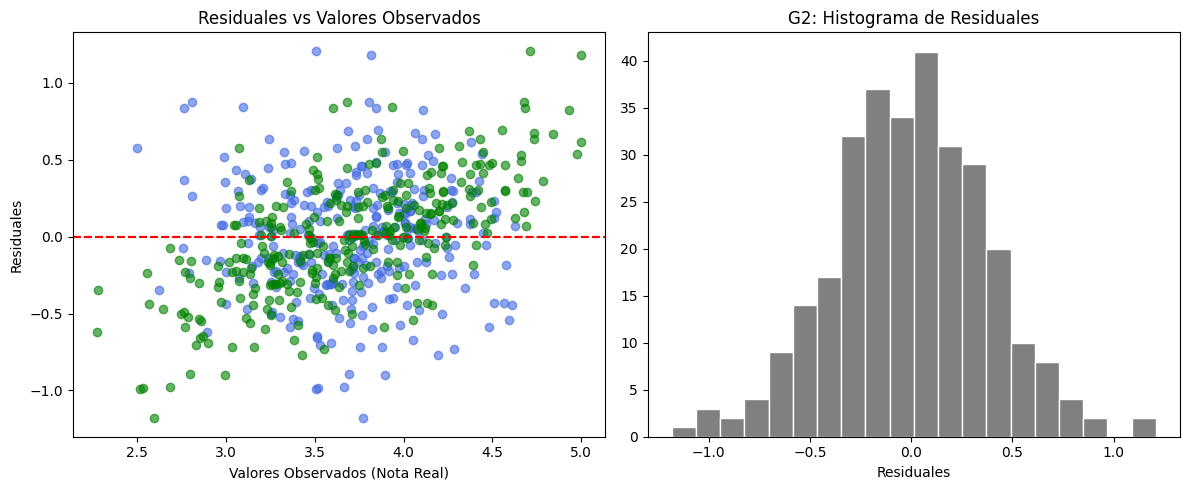

--- Tabla de Coeficientes Modelo M3b ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.001       0.274       1.024
horas10        0.4117      0.089      4.610      0.000       0.236       0.587
asistencia     0.0106      0.002      4.817      0.000       0.006       0.015
promedio       0.5753      0.050     11.422      0.000       0.476       0.674


In [6]:
# =====================================================
# ESPACIO DE TRABAJO — ESCRIBE AQUÍ TU SOLUCIÓN
# =====================================================

# TIP para ajustar:
# X = sm.add_constant(df[['horas','asistencia','promedio']])
# m3 = sm.OLS(df['nota'], X).fit()
# m3.summary()

# 1) Ajusta M3

X = sm.add_constant(df[['horas', 'asistencia', 'promedio']])
m3 = sm.OLS(df['nota'], X).fit()
print(m3.summary())

# 2) Interpreta coeficientes (nota = b0 + b1[horas] + b2[asistencia] + b3[promedio])
# Por cada hora de estudio la nota del estudiante sube en 0.0412 puntos
# Por cada porciento de asistencia la nota del estudiante sube en 0.0406 puntos
# Por unidad obtenida en el promedio previo la nota del estudiante sube en 0.5753 puntos
# Si un estudiante estudia 5 horas, su puntaje final aumentará 0.2060, esto si su promedio y asistencia se mantienen constantes

# 3) Significancia + IC
# H0: CoefVar = 0
# H1: CoefVar =! 0
# La hipotesis nula de los 3 coeficientes se rechaza con un 5% de significacncia dado que los 3 tienen un "p-valor < 0", esto significa que las variables si tienen un impacto en la nota final
# En ninguno de los 3 Intervalos de Confianza se incluye al 0, por lo que el efecto de las tres variables siempre va a ser positivo

# 4) Residuales + gráficas
valores_ajustados = m3.fittedvalues
residuales = m3.resid

# 7. Generar las 2 gráficas
plt.figure(figsize=(12, 5))

# (G1) Residuales vs Ajustados
plt.subplot(1, 2, 1)
plt.scatter(valores_ajustados, residuales, alpha=0.6, color='royalblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('G1: Residuales vs Ajustados')
plt.xlabel('Valores Ajustados (Predichos)')
plt.ylabel('Residuales')

# (G2) Histograma de residuales
plt.subplot(1, 2, 2)
plt.hist(residuales, bins=20, color='gray', edgecolor='white')
plt.title('G2: Histograma de Residuales')
plt.xlabel('Residuales')

plt.tight_layout()
plt.show()

# 5) Modelo con horas10 y comparación
df['horas10'] = df['horas'] / 10

# Definir variables para M3b
y = df['nota']
X_b = df[['horas10', 'asistencia', 'promedio']]
X_b = sm.add_constant(X_b)

# Ajustar el nuevo modelo
modelo_m3b = sm.OLS(y, X_b).fit()

# Mostrar solo la tabla de coeficientes para comparar
print("--- Tabla de Coeficientes Modelo M3b ---")
print(modelo_m3b.summary().tables[1])

pass

Text(0, 0.5, 'Residuales')

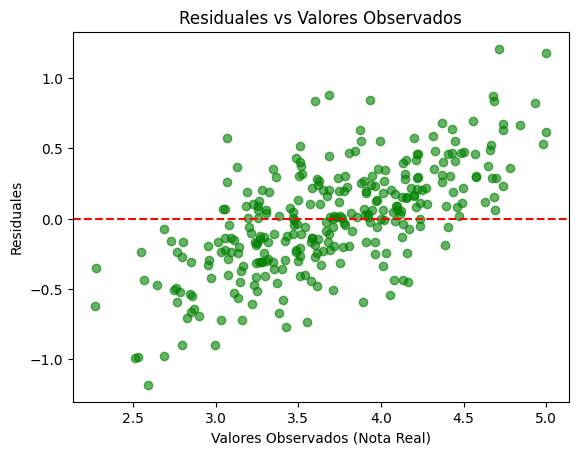

In [5]:
valores_observados = df['nota']

# Opción B: Directamente desde el objeto del modelo (útil si hiciste limpieza de datos)
valores_observados = m3.model.endog

# Para usarlos en la gráfica de la Parte 3:
plt.scatter(valores_observados, residuales, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuales vs Valores Observados')
plt.xlabel('Valores Observados (Nota Real)')
plt.ylabel('Residuales')

El modelo propuesto en el ejercicio muestra que las tres variables explicativas tienen una relación positiva y significativa con la nota final, estas tres aumentan la nota final en 0.0412 por cada hora de estudio, 0.0106 por cada porcentaje de asistencia y 0.5753 por cada unidad de promedio obtenida anteriormente, cada una si se mantienen las demas variables constantes.
Dado que los p-valor de las tres variables son 0 y aparte el 0 no se incluye en los intervalos de confianza de las tres variables, se rechaza la hipotesis nula.
El grafico de resiudales muestra que los puntos no siguen ningun patrón, según esto se puede concluir que se cumplen los supuestos de linealidad y homocedasticidad. El cambio de unidades de horas a decenas de horas no tiene ningun impacto en el modelo ya que el coeficiente es proporcional a la nueva variable, siendo la unica diferencia la interpretacion de esta variable, no siendo que el puntaje aumenta por hora si no que el puntaje aumenta por diez horas de estudio.